# Загрузка датасета и импорты

In [385]:
import pandas as pd
from IPython.display import display
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    LassoCV
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [307]:
df = pd.read_csv("used_cars.csv")

# Гипотезы

1. Автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с аварийной историей.
2. Добавление элементарных признаков, извлечённых из engine, уменьшит ошибку модели на тестовой выборке.
3. Признак horsepower, извлечённый из столбца engine, войдёт в число наиболее важных признаков модели на основе деревьев.
4. Random Forest покажет меньшую ошибку на тестовой выборке, чем линейная регрессия.
5. Обучение линейной регрессии на log(price) уменьшит MAE на исходной шкале цены по сравнению с обучением непосредственно на price.
6. Медианная цена электромобилей и гибридных автомобилей выше медианной цены автомобилей с бензиновым двигателем.
7. Lasso-регрессия занулит коэффициент хотя бы одного из двух сильно коррелирующих признаков — cylinders или engine_volume.

# EDA

## Знакомство с данными

In [308]:
print(df.shape)

(4009, 12)


In [309]:
display(df.head(10))

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [310]:
display(df.sample(10))

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2450,Lexus,GX 460 Luxury,2020,"37,366 mi.",Gasoline,4.6L V8 32V MPFI DOHC,6-Speed Automatic,White,–,NaN,NaN,"$51,890"
1546,Chevrolet,Tahoe LT,2018,"55,000 mi.",Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$37,900"
1854,Chevrolet,Trailblazer RS,2022,"42,479 mi.",Gasoline,1.3L I3 12V GDI DOHC Turbo,9-Speed Automatic,Mosaic Black Metallic,Jet Black,None reported,Yes,"$28,495"
1828,Lexus,IS 300 Base,2018,"16,000 mi.",Gasoline,260.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Brown,At least 1 accident or damage reported,Yes,"$30,500"
3885,Mercedes-Benz,S-Class S 550 4MATIC,2016,"67,280 mi.",Gasoline,449.0HP 4.7L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes,"$41,999"
2162,RAM,1500 Longhorn,2019,"76,249 mi.",Gasoline,5.7L V8 16V MPFI OHV,8-Speed Automatic,Diamond Black,Mountain Brown,At least 1 accident or damage reported,NaN,"$40,995"
2459,Mercedes-Benz,E-Class E 350 4MATIC,2010,"67,800 mi.",Gasoline,268.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,None reported,Yes,"$13,999"
773,Lexus,GX 470 Base,2008,"123,500 mi.",Gasoline,263.0HP 4.7L 8 Cylinder Engine Gasoline Fuel,A/T,White,Gray,At least 1 accident or damage reported,Yes,"$14,500"
60,Volvo,XC90 Hybrid T8 R-Design,2018,"40,000 mi.",Plug-In Hybrid,400.0HP 2.0L 4 Cylinder Engine Plug-In Electri...,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$42,000"
1477,Bentley,Arnage R,2003,"55,050 mi.",Gasoline,400.0HP 6.75L 8 Cylinder Engine Gasoline Fuel,4-Speed A/T,Gray,Gray,None reported,Yes,"$34,995"


In [311]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB
None


Сразу видим, что milage и price - строки, но по сущности числовой признак. Поменяем сейчас, чтобы дальше смотреть характеристики для чисел.

In [312]:
df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)', expand=False)
    .astype(int)
)

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [313]:
print(df.describe(include='all'))

       brand    model   model_year         milage fuel_type  \
count   4009     4009  4009.000000    4009.000000      3839   
unique    57     1898          NaN            NaN         7   
top     Ford  M3 Base          NaN            NaN  Gasoline   
freq     386       30          NaN            NaN      3309   
mean     NaN      NaN  2015.515590   64717.551010       NaN   
std      NaN      NaN     6.104816   52296.599459       NaN   
min      NaN      NaN  1974.000000     100.000000       NaN   
25%      NaN      NaN  2012.000000   23044.000000       NaN   
50%      NaN      NaN  2017.000000   52775.000000       NaN   
75%      NaN      NaN  2020.000000   94100.000000       NaN   
max      NaN      NaN  2024.000000  405000.000000       NaN   

                            engine transmission ext_col int_col  \
count                         4009         4009    4009    4009   
unique                        1146           62     319     156   
top     2.0L I4 16V GDI DOHC Turbo        

In [314]:
data_info = pd.DataFrame(columns=['Признак', 'Тип', 'Пропуски', 'Уникальные значения'])

data_info.loc[len(data_info)]=['brand', 'категориальный', df['brand'].isna().sum(), df['brand'].unique().size]

data_info.loc[len(data_info)] = ['model', 'категориальный', df['model'].isna().sum(), df['model'].unique().size]

data_info.loc[len(data_info)] = ['model_year', 'числовой', df['model_year'].isna().sum(), df['model_year'].unique().size]

data_info.loc[len(data_info)] = ['milage', 'числовой', df['milage'].isna().sum(), df['milage'].unique().size]

data_info.loc[len(data_info)] = ['fuel_type', 'категориальный', df['fuel_type'].isna().sum(), df['fuel_type'].unique().size]

data_info.loc[len(data_info)] = ['engine', 'составной', df['engine'].isna().sum(), df['engine'].unique().size]

data_info.loc[len(data_info)] = ['transmission', 'составной', df['transmission'].isna().sum(), df['transmission'].unique().size]

data_info.loc[len(data_info)] = ['ext_col', 'категориальный', df['ext_col'].isna().sum(), df['ext_col'].unique().size]

data_info.loc[len(data_info)] = ['int_col', 'категориальный', df['int_col'].isna().sum(), df['int_col'].unique().size]

data_info.loc[len(data_info)] = ['accident', 'бинарный', df['accident'].isna().sum(), df['accident'].unique().size]

data_info.loc[len(data_info)] = ['clean_title', 'бинарный', df['clean_title'].isna().sum(), df['clean_title'].unique().size]

data_info.loc[len(data_info)] = ['price', 'числовая целевая', df['price'].isna().sum(), df['price'].unique().size]

In [315]:
data_info.head(12)

,Признак,Тип,Пропуски,Уникальные значения
0,brand,категориальный,0,57
1,model,категориальный,0,1898
2,model_year,числовой,0,34
3,milage,числовой,0,2818
4,fuel_type,категориальный,170,8
5,engine,составной,0,1146
6,transmission,составной,0,62
7,ext_col,категориальный,0,319
8,int_col,категориальный,0,156
9,accident,бинарный,113,3


Замечаем, что есть составные признаки, которые можно разделить на несколько более элементарных признаков.

## Разбиение составных признаков

Добавляем исходные элементарные признаки:

In [316]:
base_columns = [
    'brand',
    'model',
    'model_year',
    'milage',
    'fuel_type',
    'ext_col',
    'int_col',
    'accident',
    'clean_title',
    'price'
]

df_features = df[base_columns].copy()

display(df_features.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,NaN,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,NaN,34999


### engine

`engine` встречается в нескольких вариантах, например:

1. `354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid`
2. `2.0L I4 16V GDI DOHC Turbo`
3. `3.5 Liter DOHC`
4. `550.0HP 5.0L V8 Cylinder Engine Supercharged`

Из него можно извлечь следующие элементарные признаки:

| Новый признак     | Смысл нового признака                | Тип            | Пример                                                   |
| ----------------- | ------------------------------------ | -------------- | -------------------------------------------------------- |
| `horsepower`      | Мощность двигателя в лошадиных силах | Числовой       | `300.0`, `450.0`                                         |
| `engine_volume`   | Рабочий объём двигателя в литрах     | Числовой       | `2.0`, `3.5`                                             |
| `cylinders`       | Количество цилиндров двигателя       | Числовой       | `4`, `6`, `8`                                            |
| `engine_config`   | Конфигурация двигателя               | Категориальный | `I4`, `I6`, `V6`, `V8`, `H6`, `ROTARY`                   |
| `fuel_type`       | Тип используемого топлива            | Категориальный | `Gasoline`, `Diesel`, `Flex Fuel`, `Gas/Electric Hybrid` |
| `is_turbo`        | Наличие турбонаддува                 | Бинарный       | `0`, `1`                                                 |
| `is_supercharged` | Наличие механического нагнетателя    | Бинарный       | `0`, `1`                                                 |
| `valves`          | Количество клапанов двигателя        | Числовой       | `16`, `24`, `32`                                         |
| `camshaft_type`   | Тип газораспределительного механизма | Категориальный | `DOHC`, `SOHC`, `OHV`                                    |

In [317]:
### horsepower
df_features['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

### engine_volume
df_features['engine_volume'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*(?:L|Liter)').astype(float)

### engine_config
engine_configs = [
    r'V\d+',
    r'I\d+',
    r'Straight\s*\d+',
    r'Flat\s*\d+',
    r'W\d+',
    r'H\d+',
    r'Rotary'
]

pattern_engine_config = '|'.join(engine_configs)

df_features['engine_config'] = df['engine'].str.extract(
    f'\\b({pattern_engine_config})\\b',
    flags=re.IGNORECASE
)

# Приводим разные обозначения одной конфигурации к единому формату
engine_config_map = {
    r'(?i)^Straight\s*(\d+)$': r'I\1',
    r'(?i)^Flat\s*(\d+)$': r'H\1'
}

df_features['engine_config'] = (
    df_features['engine_config']
    .replace(engine_config_map, regex=True)
    .str.upper()
)


### cylinders
# Извлекаем количество цилиндров из конфигурации (если там есть цифра)
df_features['cylinders_from_config'] = df_features['engine_config'].str.extract(r'(\d+)').astype('Int64')

# Если есть явное "X Cylinder", берём его, иначе берём из конфигурации
df_features['cylinders'] = df['engine'].str.extract(r'(\d+)\s*Cylinder').astype('Int64')
df_features['cylinders'] = df_features['cylinders'].fillna(df_features['cylinders_from_config'])

# Удаляем промежуточный
df_features.drop(columns=['cylinders_from_config'], inplace=True)

### is_turbo
df_features['is_turbo'] = df['engine'].str.contains(r'\bTurbo\b', flags=re.IGNORECASE, na=False).astype(int)

### is_supercharged
df_features['is_supercharged'] = df['engine'].str.contains(r'\bSupercharged\b', flags=re.IGNORECASE, na=False).astype(int)

### valves
df_features['valves'] = df['engine'].str.extract(r'(\d+)V').astype('Int64')

### camshaft_type
df_features['camshaft_type'] = df['engine'].str.extract(r'(DOHC|SOHC|OHV|OHC)')

Поскольку fuel_type есть в исходных данных, возьмём оттуда fuel_type, а пропуски заполним информацией из engine

In [318]:
df_features['fuel_type'] = (
    df_features['fuel_type']
    .replace({
        '–': pd.NA,
        'not supported': pd.NA
    })
)

In [319]:
fuel_types = [
    'Gasoline/Mild Electric Hybrid',
    'Gas/Electric Hybrid',
    'Mild Electric Hybrid',
    'Plug-In Hybrid',
    'E85 Flex Fuel',
    'Flex Fuel',
    'Gasoline',
    'Diesel',
    'Hybrid',
    'Electric'
]

pattern_fuel = '|'.join(fuel_types)

fuel_from_engine = df['engine'].str.extract(
    f'({pattern_fuel})',
    flags=re.IGNORECASE,
    expand=False,
)

In [320]:
df_features['fuel_type'] = (
    df_features['fuel_type']
    .fillna(fuel_from_engine)
)

In [321]:
display(df_features.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price,horsepower,engine_volume,engine_config,cylinders,is_turbo,is_supercharged,valves,camshaft_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300,300.0,3.7,V6,6,0,0,<NA>,NaN
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,NaN,3.8,V6,6,0,0,24,DOHC
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,NaN,54598,NaN,3.5,NaN,<NA>,0,0,<NA>,DOHC
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500,354.0,3.5,V6,6,0,0,<NA>,NaN
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,NaN,34999,NaN,2.0,I4,4,1,0,16,DOHC


In [322]:
df_features['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
Electric           167
E85 Flex Fuel      139
Diesel             116
NaN                 50
Plug-In Hybrid      34
Name: count, dtype: int64

В некоторых строках пропуски всё равно остались

### transmission

`transmission` встречается в нескольких вариантах, например:

1. 8-Speed Automatic
2. 6-Speed M/T
3. Automatic CVT
4. 7-Speed Automatic with Auto-Shift
5. Transmission w/Dual Shift Mode

Из него можно извлечь следующие элементарные признаки:

| Новый признак       | Смысл нового признака                               | Тип               | Пример                              |
| ------------------- | --------------------------------------------------- | ----------------- |-------------------------------------|
| `gears`             | Количество передач коробки передач                  | Числовой          | `5`, `6`, `8`, `10`                 |
| `transmission_type` | Тип коробки передач                                 | Категориальный    | `Automatic`, `Manual`, `CVT`, `DCT` |

In [323]:
### gears
df_features['gears'] = (df['transmission'].str.extract(
        r'(\d+)\s*[- ]?(?:Speed|Spd)',
        flags=re.IGNORECASE,
        expand=False
    )
    .astype('Int64')
)
single_speed_mask = df['transmission'].str.contains(
    r'Single[- ]Speed',
    na=False
)

df_features.loc[single_speed_mask, 'gears'] = 1

In [324]:
### transmission_type
transmission_types = [
    'A/T',
    'M/T',
    'CVT',
    'Automatic',
    'Manual',
    'Dual-Clutch',
    'Variable',
    'Auto-Shift',
    'Dual Shift Mode',
    'Fixed Gear'
]

pattern_trans = '|'.join(transmission_types)

df_features['transmission_type'] = (
    df['transmission']
    .str.extract(
        f'({pattern_trans})',
        flags=re.IGNORECASE,
    )
)

# Преобразуем к единому формату автомат и механику
trans_map = {
    'A/T': 'Automatic',
    'M/T': 'Manual'
}

df_features['transmission_type'] = (
    df_features['transmission_type']
    .replace(trans_map)
)

display(df_features.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,price,horsepower,engine_volume,engine_config,cylinders,is_turbo,is_supercharged,valves,camshaft_type,gears,transmission_type
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,Black,Black,At least 1 accident or damage reported,Yes,10300,300.0,3.7,V6,6,0,0,<NA>,NaN,6,Automatic
1,Hyundai,Palisade SEL,2021,34742,Gasoline,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,NaN,3.8,V6,6,0,0,24,DOHC,8,Automatic
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,Blue,Black,None reported,NaN,54598,NaN,3.5,NaN,<NA>,0,0,<NA>,DOHC,<NA>,Automatic
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,Black,Black,None reported,Yes,15500,354.0,3.5,V6,6,0,0,<NA>,NaN,7,Automatic
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,Glacier White Metallic,Black,None reported,NaN,34999,NaN,2.0,I4,4,1,0,16,DOHC,8,Automatic


## Split на train/test

In [325]:
X = df_features.drop(
    columns='price'
)

y = df_features['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

df_train_eda = X_train.copy()

df_train_eda['price'] = y_train

## Обработка пропущенных значений

Отдельно рассмотрим:

1. исходные признаки
2. новые признаки, полученные из составных

In [326]:
new_columns = [
    column
    for column in df_train_eda.columns
    if column not in base_columns
]

In [327]:
missing_base = pd.DataFrame({
    'Пропуски': (
        df_train_eda[base_columns]
        .isna()
        .sum()
    ),
    'Доля пропусков, %': (
        df_train_eda[base_columns]
        .isna()
        .mean() * 100
    ).round(2)
})

missing_base = (
    missing_base[
        missing_base['Пропуски'] > 0
    ]
    .sort_values(
        by='Доля пропусков, %',
        ascending=False
    )
)

display(missing_base)

,Пропуски,"Доля пропусков, %"
clean_title,470,14.66
accident,91,2.84
fuel_type,39,1.22


Теперь рассмотрим пропуски в новых признаках:

In [328]:
missing_new = pd.DataFrame({
    'Пропуски': (
        df_train_eda[new_columns]
        .isna()
        .sum()
    ),
    'Доля пропусков, %': (
        df_train_eda[new_columns]
        .isna()
        .mean() * 100
    ).round(2)
})

missing_new = (
    missing_new[
        missing_new['Пропуски'] > 0
    ]
    .sort_values(
        by='Доля пропусков, %',
        ascending=False
    )
)

display(missing_new)

,Пропуски,"Доля пропусков, %"
valves,2798,87.25
camshaft_type,2759,86.03
engine_config,1799,56.10
gears,1461,45.56
horsepower,633,19.74
cylinders,324,10.10
engine_volume,162,5.05
transmission_type,18,0.56


В признаках `valves` и `camshaft_type` отсутствует более 80% значений. Заполнение такого количества пропусков медианой или наиболее частой категорией привело бы к появлению большого количества искусственных значений.

Поэтому удалим эти признаки.

In [329]:
columns_to_drop = [
    'valves',
    'camshaft_type'
]

df_train_eda.drop(
    columns=columns_to_drop,
    inplace=True
)

X_train.drop(
    columns=columns_to_drop,
    inplace=True
)

X_test.drop(
    columns=columns_to_drop,
    inplace=True
)

Для построения графиков заполним пропуски. Test и train заполним уже в пайплайне.

In [330]:
df_train_eda_filled = (
    df_train_eda.copy()
)

Пропуски в категориальных признаках заполним отдельной категорией Unknown.
Не будем заменять их наиболее частым значением, поскольку отсутствие информации само по себе может быть связано с ценой автомобиля.

In [331]:
categorical_columns_with_missing = [
    'fuel_type',
    'engine_config',
    'transmission_type',
    'accident',
    'clean_title'
]

for column in categorical_columns_with_missing:
    df_train_eda_filled[column] = (
        df_train_eda_filled[column]
        .fillna('Unknown')
    )

Пропуски в числовых признаках заполним медианой. Медиана менее чувствительна к выбросам, чем среднее арифметическое.

In [332]:
numeric_columns_with_missing = [
    'horsepower',
    'engine_volume',
    'cylinders',
    'gears'
]

for column in numeric_columns_with_missing:
    train_median = (
        df_train_eda_filled[column]
        .median()
    )

    df_train_eda_filled[column] = (
        df_train_eda_filled[column]
        .fillna(train_median)
    )

In [333]:
missing_data_after = pd.DataFrame({
    'Пропуски': df_train_eda_filled.isna().sum(),
    'Доля пропусков, %': (
        df_train_eda_filled.isna().mean() * 100
    ).round(2)
})

display(
    missing_data_after[
        missing_data_after['Пропуски'] > 0
    ]
)

,Пропуски,"Доля пропусков, %"


## Графический анализ данных

### распределение цены

In [334]:
df_train_eda_filled['price'] = y_train

Сначала рассмотрим распределение цены автомобилей.

In [335]:
print(
    'Средняя цена:',
    round(df_train_eda_filled['price'].mean(), 2)
)

print(
    'Медианная цена:',
    round(df_train_eda_filled['price'].median(), 2)
)

print(
    'Максимальная цена:',
    df_train_eda_filled['price'].max()
)

Средняя цена: 43125.76
Медианная цена: 31300.0
Максимальная цена: 749950


В датасете присутствуют отдельные автомобили с очень высокой ценой. Из-за них основная часть распределения может быть плохо видна. Поэтому для первого графика исключим 1% самых дорогих автомобилей

Также построим распределение log(price). Логарифмирование уменьшает влияние очень дорогих автомобилей и позволяет проверить целесообразность обучения модели на логарифме целевой переменной.

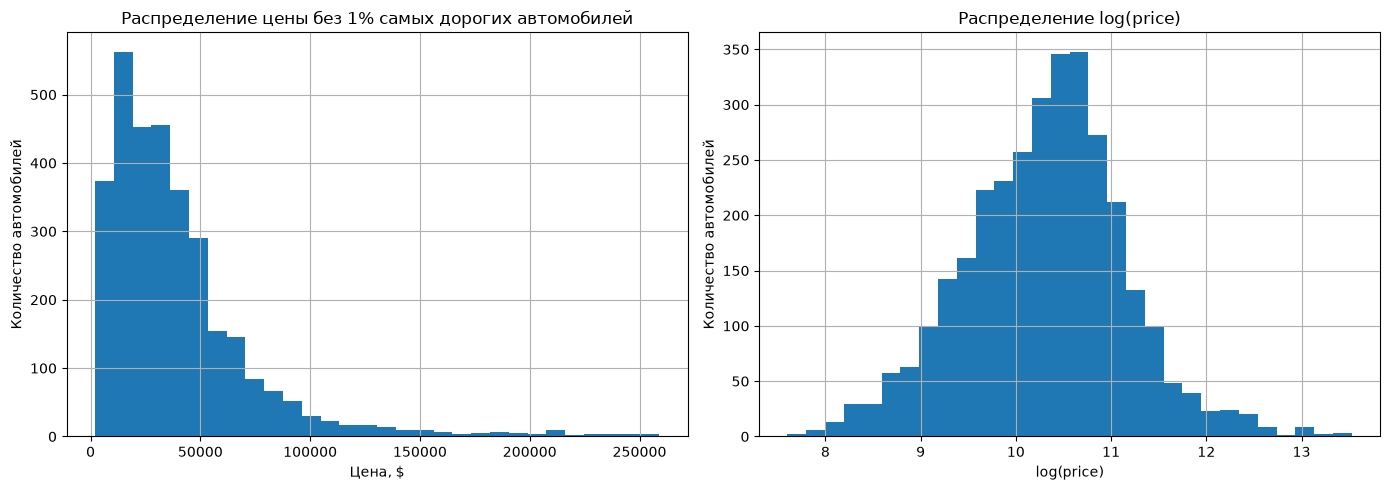

In [336]:
price_99 = (
    df_train_eda_filled['price']
    .quantile(0.99)
)

price_without_extreme = df_train_eda_filled[
    df_train_eda_filled['price'] <= price_99
]['price']

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].hist(
    price_without_extreme,
    bins=30
)

axes[0].set_title(
    'Распределение цены без 1% самых дорогих автомобилей'
)

axes[0].set_xlabel('Цена, $')
axes[0].set_ylabel('Количество автомобилей')
axes[0].grid(True)

axes[1].hist(
    np.log1p(df_train_eda_filled['price']),
    bins=30
)

axes[1].set_title(
    'Распределение log(price)'
)

axes[1].set_xlabel('log(price)')
axes[1].set_ylabel('Количество автомобилей')
axes[1].grid(True)

fig.tight_layout()
plt.show()

Средняя цена заметно выше медианной цены. Кроме того, на гистограмме присутствует длинный правый хвост.

Следовательно, распределение цены скошено вправо из-за небольшого количества очень дорогих автомобилей. Поэтому медиана лучше описывает цену типичного автомобиля, чем среднее арифметическое.

## Распределение автомобилей по маркам

Поскольку уникальных марок много, отобразим десять наиболее часто встречающихся.

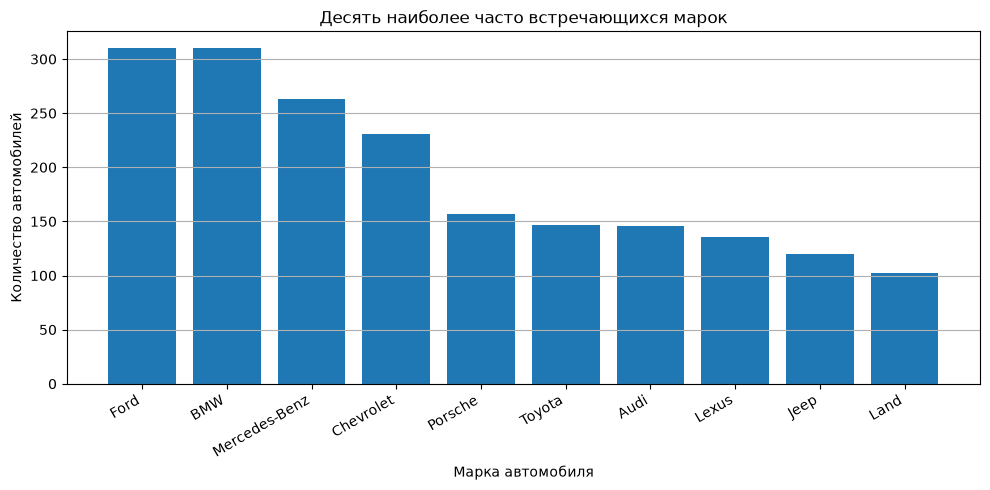

In [337]:
brand_counts = (
    df_train_eda_filled['brand']
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

x = np.arange(
    len(brand_counts)
)

ax.bar(
    x,
    brand_counts.values
)

ax.set_xticks(x)

ax.set_xticklabels(
    brand_counts.index,
    rotation=30,
    ha='right'
)

ax.set_title(
    'Десять наиболее часто встречающихся марок'
)

ax.set_xlabel('Марка автомобиля')
ax.set_ylabel('Количество автомобилей')
ax.grid(axis='y')

fig.tight_layout()
plt.show()

Некоторые марки встречаются значительно чаще остальных.

Это следует учитывать при анализе зависимости цены от марки автомобиля: результаты для редко встречающихся марок могут быть менее устойчивыми.

## Цена и аварийная история

Проверим гипотезу о том, что автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с аварийной историей.

Чтобы отдельные очень дорогие автомобили не сжимали основную часть графика, ограничим ось Y значением 99-го процентиля.

In [338]:
accident_categories = [
    'None reported',
    'At least 1 accident or damage reported'
]

accident_labels = [
    'Без аварий',
    'Есть авария или повреждение'
]

price_by_accident = []

for category in accident_categories:
    prices = df_train_eda_filled[
        df_train_eda_filled['accident'] == category
    ]['price']

    price_by_accident.append(prices)

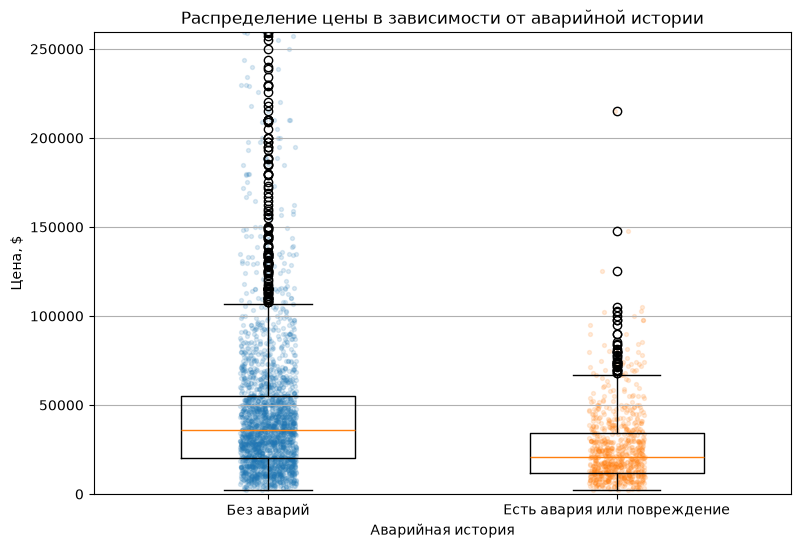

In [339]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.boxplot(
    price_by_accident,
    widths=0.5
)

x = np.arange(
    1,
    len(accident_categories) + 1
)

for i in range(
    len(price_by_accident)
):
    y = price_by_accident[i]

    x_jitter = (
        x[i]
        + np.random.uniform(
            -0.08,
            0.08,
            len(y)
        )
    )

    ax.scatter(
        x_jitter,
        y,
        s=8,
        alpha=0.15
    )

ax.set_xticks(x)
ax.set_xticklabels(
    accident_labels
)

ax.set_title(
    'Распределение цены в зависимости от аварийной истории'
)

ax.set_xlabel(
    'Аварийная история'
)

ax.set_ylabel('Цена, $')

ax.set_ylim(
    0,
    df_train_eda_filled['price'].quantile(0.99)
)

ax.grid(axis='y')

plt.show()

Сравнивать группы лучше по медианной цене, поскольку средняя цена чувствительна к редким очень дорогим автомобилям.

Автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с авариями или повреждениями.
Следовательно, полученный результат согласуется с выдвинутой гипотезой.

## Цена и тип топлива

Проверим гипотезу о том, что медианная цена электромобилей и гибридных автомобилей выше медианной цены автомобилей с бензиновым двигателем.

,count,median,mean
fuel_group,,,
Gasoline,2643,29950.0,42608.795687
Hybrid,188,46500.0,51658.063830
Electric,125,49500.0,55658.424000


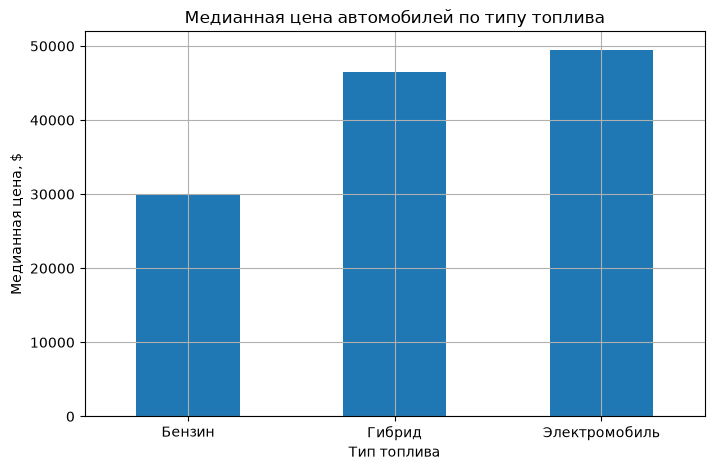

In [340]:
fuel = df_train_eda_filled['fuel_type']

fuel_stats = (
    df_train_eda_filled
    .assign(
        fuel_group=np.select(
            [
                fuel.str.contains('Hybrid', case=False, na=False),
                fuel.str.fullmatch('Electric', case=False, na=False),
                fuel.str.fullmatch('Gasoline', case=False, na=False)
            ],
            ['Hybrid', 'Electric', 'Gasoline'],
            default='Other'
        )
    )
    .query("fuel_group != 'Other'")
    .groupby('fuel_group')['price']
    .agg(['count', 'median', 'mean'])
    .reindex(['Gasoline', 'Hybrid', 'Electric'])
)

display(fuel_stats)

ax = fuel_stats['median'].plot.bar(
    figsize=(8, 5),
    grid=True
)

ax.set(
    title='Медианная цена автомобилей по типу топлива',
    xlabel='Тип топлива',
    ylabel='Медианная цена, $'
)

ax.set_xticklabels(
    ['Бензин', 'Гибрид', 'Электромобиль'],
    rotation=0
)

plt.show()

Медианные цены автомобилей различаются в зависимости от типа топлива.

## Связь цены с числовыми признаками

Для предварительной проверки зависимости цены от мощности двигателя построим корреляционную матрицу.

In [341]:
correlation_columns = [
    'model_year',
    'milage',
    'horsepower',
    'engine_volume',
    'cylinders',
    'gears',
    'is_turbo',
    'is_supercharged',
    'price'
]

corr_data = (
    df_train_eda_filled[
        correlation_columns
    ]
    .copy()
)

In [342]:
corr_matrix = corr_data.corr()

display(corr_matrix)

,model_year,milage,horsepower,engine_volume,cylinders,gears,is_turbo,is_supercharged,price
model_year,1.000000,-0.617012,0.243669,-0.109381,-0.116453,0.320544,0.236060,0.031886,0.353262
milage,-0.617012,1.000000,-0.303271,0.072802,0.014159,-0.215312,-0.202382,-0.033371,-0.441987
horsepower,0.243669,-0.303271,1.000000,0.518531,0.587357,0.076658,-0.046829,-0.007210,0.388203
engine_volume,-0.109381,0.072802,0.518531,1.000000,0.863433,0.002949,-0.148130,0.041737,0.212811
cylinders,-0.116453,0.014159,0.587357,0.863433,1.000000,0.023650,-0.105641,0.039376,0.312136
gears,0.320544,-0.215312,0.076658,0.002949,0.023650,1.000000,0.188821,0.034308,0.150062
is_turbo,0.236060,-0.202382,-0.046829,-0.148130,-0.105641,0.188821,1.000000,-0.012174,0.193385
is_supercharged,0.031886,-0.033371,-0.007210,0.041737,0.039376,0.034308,-0.012174,1.000000,0.033697
price,0.353262,-0.441987,0.388203,0.212811,0.312136,0.150062,0.193385,0.033697,1.000000


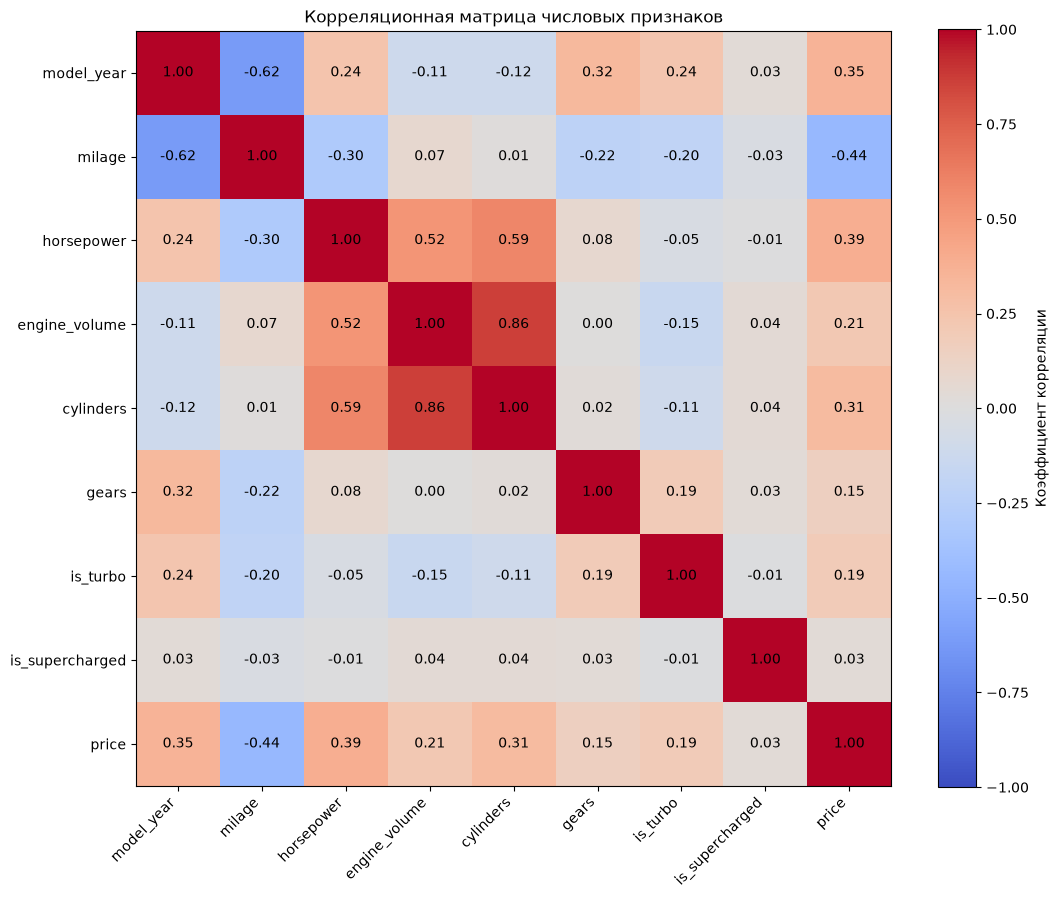

In [343]:
fig, ax = plt.subplots(
    figsize=(11, 9)
)

image = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap='coolwarm'
)

ax.set_xticks(
    np.arange(
        len(correlation_columns)
    )
)

ax.set_yticks(
    np.arange(
        len(correlation_columns)
    )
)

ax.set_xticklabels(
    correlation_columns,
    rotation=45,
    ha='right'
)

ax.set_yticklabels(
    correlation_columns
)

for i in range(
    corr_matrix.shape[0]
):
    for j in range(
        corr_matrix.shape[1]
    ):
        ax.text(
            j,
            i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

ax.set_title(
    'Корреляционная матрица числовых признаков'
)

fig.colorbar(
    image,
    ax=ax,
    label='Коэффициент корреляции'
)

fig.tight_layout()
plt.show()

In [344]:
price_correlations = (
    corr_matrix['price']
    .drop('price')
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    price_correlations.to_frame(
        name='Корреляция с price'
    )
)

,Корреляция с price
milage,-0.441987
horsepower,0.388203
model_year,0.353262
cylinders,0.312136
engine_volume,0.212811
is_turbo,0.193385
gears,0.150062
is_supercharged,0.033697


Наиболее сильная связь с ценой наблюдается у признака `milage`. Связь отрицательная.

Между мощностью двигателя `horsepower` и ценой наблюдается положительная корреляция `0.39`. Это предварительно подтверждает гипотезу о том, что более мощные автомобили в среднем стоят дороже. Однако связь является слабой.

Наиболее сильная зависимость наблюдается между признаками `engine_volume` и `cylinders`: коэффициент корреляции равен `0.86`.


Поскольку `engine_volume` является более подробным числовым признаком и содержит меньше пропусков, можно оставить его, а `cylinders` удалить.

In [345]:
accident_price = (
    df_train_eda_filled[
        df_train_eda_filled['accident'].isin(
            accident_categories
        )
    ]
    .groupby('accident')['price']
    .agg([
        'count',
        'median',
        'mean'
    ])
)

display(accident_price)

,count,median,mean
accident,,,
At least 1 accident or damage reported,784,20925.0,26054.600765
None reported,2332,35750.0,48578.381218


# Подготовка признаков к моделированию

In [346]:
display(X_train.head())

,brand,model,model_year,milage,fuel_type,ext_col,int_col,accident,clean_title,horsepower,engine_volume,engine_config,cylinders,is_turbo,is_supercharged,gears,transmission_type
2473,Ford,Explorer Platinum,2018,73049,Gasoline,Gray,Ebony Black,At least 1 accident or damage reported,Yes,NaN,3.5,V6,6,1,0,6,Automatic
1338,GMC,Yukon XL AT4,2023,9980,Gasoline,Black,Black,None reported,Yes,355.0,5.3,NaN,8,0,0,10,Automatic
1613,BMW,M3 Base,2016,55250,Gasoline,Blue,White,None reported,Yes,425.0,3.0,I6,6,0,0,6,Manual
1610,Lexus,IS 350 Base,2017,77300,Gasoline,White,Black,None reported,Yes,306.0,3.5,V6,6,0,0,6,Automatic
2600,Ford,Focus SE,2018,33700,E85 Flex Fuel,Gray,Black,At least 1 accident or damage reported,Yes,160.0,2.0,NaN,4,0,0,<NA>,Automatic


## Пайплайн предобработки

Предобработку признаков будем выполнять внутри Pipeline.

Для числовых признаков:
1. Пропуски заполняются медианой
2. Создаются индикаторы отсутствующих значений
3. Числовые признаки масштабируются

Для категориальных признаков:
1. Пропуски заполняются отдельной категорией `Unknown`
2. Применяется One-Hot Encoding
3. Неизвестные категории в тестовой выборке игнорируются

In [347]:
def make_preprocessor(X):
    categorical_columns = (
        X.select_dtypes(
            include=[
                'object',
                'category',
                'string'
            ]
        )
        .columns
        .tolist()
    )

    numeric_columns = [
        column
        for column in X.columns
        if column not in categorical_columns
    ]

    numeric_transformer = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='median',
                add_indicator=True
            )
        ),
        (
            'scaler',
            StandardScaler()
        )
    ])

    categorical_transformer = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='constant',
                fill_value='Unknown'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                min_frequency=5
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            'numeric',
            numeric_transformer,
            numeric_columns
        ),
        (
            'categorical',
            categorical_transformer,
            categorical_columns
        )
    ])

    return preprocessor

## Обучение

Обучим несколько моделей для прогнозирования цены автомобиля:

1. линейную регрессию(с и без признаков из engine);
2. Lasso-регрессию;
3. случайный лес;
4. линейную регрессию на `log(price)`.

В качестве основной метрики выберем MAE, поскольку она показывает среднюю абсолютную ошибку в долларах и меньше зависит от отдельных экстремально дорогих автомобилей, чем RMSE.

RMSE и R² будем использовать как дополнительные метрики.

In [348]:
print(
    'Размер обучающей выборки:',
    X_train.shape
)

print(
    'Размер тестовой выборки:',
    X_test.shape
)

Размер обучающей выборки: (3207, 17)
Размер тестовой выборки: (802, 17)


### Подготовка наборов признаков

Из-за высокой корреляции между `cylinders` и `engine_volume` для линейной регрессии, случайного леса и линейной регрессии на `log(price)` удалим `cylinders`.

Для Lasso-регрессии сохраним полный набор признаков, включая `cylinders` и `engine_volume`. Это позволит проверить гипотезу о том, что L1-регуляризация самостоятельно занулит коэффициент хотя бы одного из этих сильно коррелирующих признаков.

In [349]:
X_train_without_cylinders = (
    X_train.drop(
        columns=['cylinders']
    )
)

X_test_without_cylinders = (
    X_test.drop(
        columns=['cylinders']
    )
)

## Расчёт метрик

In [350]:
model_results = []

def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    model_results.append({
        'Модель': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

    print(
        'MAE:',
        round(mae, 2)
    )

    print(
        'RMSE:',
        round(rmse, 2)
    )

    print(
        'R2:',
        round(r2, 4)
    )

In [351]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Линейная регрессия

In [352]:
linear_model = Pipeline([
    (
        'preprocessor',
        make_preprocessor(
            X_train_without_cylinders
        )
    ),
    (
        'model',
        LinearRegression()
    )
])

In [353]:
linear_model.fit(
    X_train_without_cylinders,
    y_train
)

linear_predictions = (
    linear_model.predict(
        X_test_without_cylinders
    )
)

evaluate_model(
    'Linear Regression',
    y_test,
    linear_predictions
)

MAE: 22202.29
RMSE: 136229.02
R2: 0.092


Проверим гипотезу о том, что добавление элементарных признаков, извлечённых из `engine`, уменьшает ошибку модели.

Для этого обучим вторую линейную регрессию без соответсвующих признаков.

In [354]:
engine_columns = [
    'horsepower',
    'engine_volume',
    'engine_config',
    'is_turbo',
    'is_supercharged'
]

In [355]:
X_train_without_engine = (
    X_train_without_cylinders.drop(
        columns=engine_columns
    )
)

X_test_without_engine = (
    X_test_without_cylinders.drop(
        columns=engine_columns
    )
)

In [356]:
linear_without_engine = Pipeline([
    (
        'preprocessor',
        make_preprocessor(
            X_train_without_engine
        )
    ),
    (
        'model',
        LinearRegression()
    )
])

In [380]:
linear_without_engine.fit(
    X_train_without_engine,
    y_train
)

predictions_without_engine = (
    linear_without_engine.predict(
        X_test_without_engine
    )
)

evaluate_model(
    'Linear Regression(without engine)',
    y_test,
    predictions_without_engine
)

MAE: 24156.19
RMSE: 137927.74
R2: 0.0693


In [381]:
ae_with_engine = mean_absolute_error(
    y_test,
    linear_predictions
)

mae_without_engine = mean_absolute_error(
    y_test,
    predictions_without_engine
)

engine_comparison = pd.DataFrame({
    'Вариант': [
        'С признаками engine',
        'Без признаков engine'
    ],
    'MAE': [
        mae_with_engine,
        mae_without_engine
    ]
})

display(engine_comparison)

,Вариант,MAE
0,С признаками engine,22202.293350
1,Без признаков engine,24156.185149


In [382]:
mae_difference= mae_without_engine - mae_with_engine
print(
    'Разница MAE:',
    round(
        mae_difference,
        2
    )
)

Разница MAE: 1953.89


## Lasso-регрессия

In [359]:
lasso_model = Pipeline([
    (
        'preprocessor',
        make_preprocessor(
            X_train
        )
    ),
    (
        'model',
        LassoCV(
            cv=3,
            max_iter=20000,
            n_jobs=-1,
            selection='random',
            random_state=42
        )
    )
])

In [360]:
lasso_model.fit(
    X_train,
    y_train
)

lasso_predictions = (
    lasso_model.predict(
        X_test
    )
)

evaluate_model(
    'Lasso Regression',
    y_test,
    lasso_predictions
)

MAE: 22014.37
RMSE: 137172.26
R2: 0.0794


In [361]:
best_alpha = (
    lasso_model[
        'model'
    ].alpha_
)

print(
    'Лучшее alpha:',
    best_alpha
)

Лучшее alpha: 22.628218837196936


Проверим коэффициенты признаков `cylinders` и `engine_volume`.

In [362]:
lasso_feature_names = (
    lasso_model[
        'preprocessor'
    ]
    .get_feature_names_out()
)

lasso_coefficients = pd.Series(
    lasso_model[
        'model'
    ].coef_,
    index=lasso_feature_names
)

display(
    lasso_coefficients[
        [
            'numeric__cylinders',
            'numeric__engine_volume',
            'numeric__horsepower'
        ]
    ].to_frame(
        name='Коэффициент'
    )
)

,Коэффициент
numeric__cylinders,-548.858241
numeric__engine_volume,4487.007690
numeric__horsepower,8278.428098


Коэффициенты признаков cylinders и engine_volume не равны нулю.

Посмотрим, сколько признаков Lasso оставила в модели.

In [364]:
selected_features = (
    lasso_coefficients[
        ~np.isclose(
            lasso_coefficients,
            0
        )
    ]
)

removed_features = (
    lasso_coefficients[
        np.isclose(
            lasso_coefficients,
            0
        )
    ]
)

print(
    'Всего признаков:',
    len(lasso_coefficients)
)

print(
    'Оставлено признаков:',
    len(selected_features)
)

print(
    'Исключено признаков:',
    len(removed_features)
)

Всего признаков: 250
Оставлено признаков: 132
Исключено признаков: 118


## Случайный лес

In [365]:
random_forest_pipeline = Pipeline([
    (
        'preprocessor',
        make_preprocessor(
            X_train_without_cylinders
        )
    ),
    (
        'model',
        RandomForestRegressor(
            random_state=42,
            n_jobs=1
        )
    )
])

In [369]:
param_grid = {
    'model__n_estimators': [
        200,
        350,
        500
    ],
    'model__max_depth': [
        15,
        25,
        None
    ],
    'model__min_samples_split': [
        2,
        5,
        10
    ],
    'model__min_samples_leaf': [
        1,
        2,
        3,
        5
    ],
    'model__max_features': [
        'sqrt',
        0.5,
        'log2'
    ]
}

In [370]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    refit='mae',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    error_score='raise',
    return_train_score=True
)

In [371]:
grid_search.fit(
    X_train_without_cylinders,
    y_train
)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15, 25, ...], 'model__max_features': ['sqrt', 0.5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'mae'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_

In [372]:
print(
    'Лучшие параметры:',
    grid_search.best_params_
)

print(
    'Лучший CV MAE:',
    round(
        -grid_search.best_score_,
        2
    )
)

Лучшие параметры: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Лучший CV MAE: 9545.27


In [373]:
best_random_forest = (
    grid_search.best_estimator_
)

random_forest_predictions = (
    best_random_forest.predict(
        X_test_without_cylinders
    )
)

evaluate_model(
    'Tuned Random Forest',
    y_test,
    random_forest_predictions
)

MAE: 16424.52
RMSE: 134398.98
R2: 0.1163


Важность признаков случайного леса

In [374]:
random_forest_feature_names = (
    best_random_forest[
        'preprocessor'
    ]
    .get_feature_names_out()
)

feature_importance = pd.Series(
    best_random_forest[
        'model'
    ].feature_importances_,
    index=random_forest_feature_names
)

feature_importance = (
    feature_importance
    .sort_values(
        ascending=False
    )
)

display(
    feature_importance
    .head(20)
    .to_frame(
        name='Важность'
    )
)

,Важность
numeric__milage,0.247838
categorical__brand_Lamborghini,0.097979
categorical__engine_config_V12,0.095544
numeric__engine_volume,0.094722
numeric__horsepower,0.086315
numeric__model_year,0.061224
categorical__brand_Rolls-Royce,0.059069
categorical__brand_Ferrari,0.028498
categorical__engine_config_H6,0.018118
categorical__brand_Porsche,0.015323


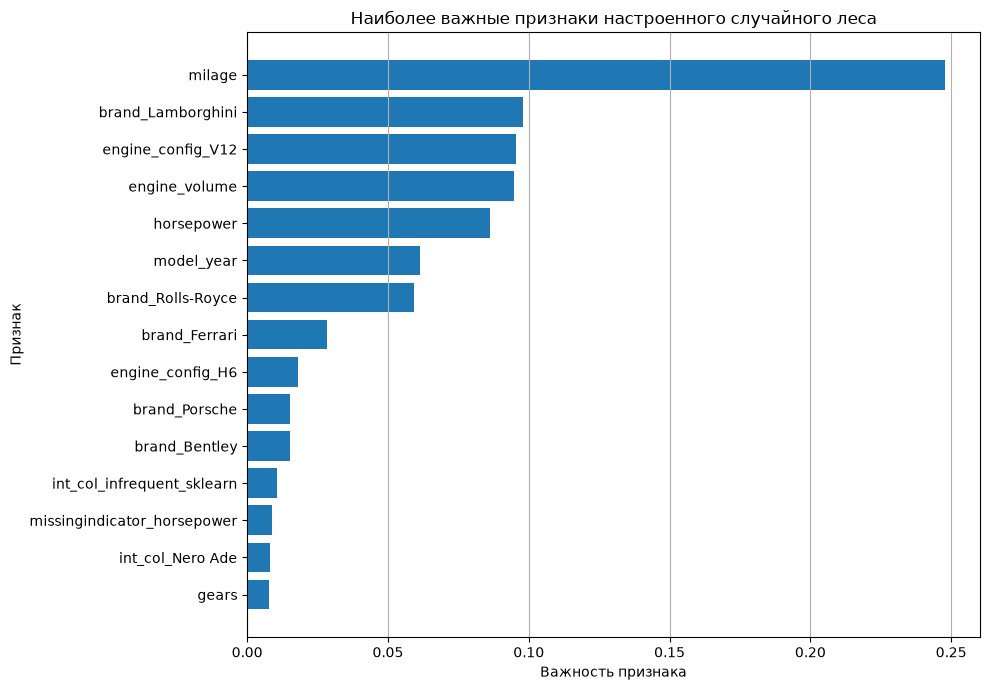

In [375]:
top_features = (
    feature_importance
    .head(15)
    .sort_values()
)

clean_feature_names = (
    top_features.index
    .str.replace(
        'numeric__',
        '',
        regex=False
    )
    .str.replace(
        'categorical__',
        '',
        regex=False
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    clean_feature_names,
    top_features.values
)

ax.set_title(
    'Наиболее важные признаки настроенного случайного леса'
)

ax.set_xlabel('Важность признака')
ax.set_ylabel('Признак')
ax.grid(axis='x')

fig.tight_layout()
plt.show()

## Линейная регрессия на log(price)

In [376]:
log_linear_model = Pipeline([
    (
        'preprocessor',
        make_preprocessor(
            X_train_without_cylinders
        )
    ),
    (
        'model',
        TransformedTargetRegressor(
            regressor=LinearRegression(),
            func=np.log1p,
            inverse_func=np.expm1
        )
    )
])

In [377]:
log_linear_model.fit(
    X_train_without_cylinders,
    y_train
)

log_price_predictions = (
    log_linear_model.predict(
        X_test_without_cylinders
    )
)

log_price_predictions = np.maximum(
    log_price_predictions,
    0
)

evaluate_model(
    'Linear Regression log(price)',
    y_test,
    log_price_predictions
)

MAE: 17051.16
RMSE: 136333.62
R2: 0.0906


## Итоговая таблица

In [384]:
results_df = pd.DataFrame(
    model_results
)

results_df = (
    results_df
    .sort_values(
        by='MAE'
    )
    .reset_index(
        drop=True
    )
)

display(results_df)

,Модель,MAE,RMSE,R2
0,Tuned Random Forest,16424.52,134398.98,0.1163
1,Linear Regression log(price),17051.16,136333.62,0.0906
2,Lasso Regression,22014.37,137172.26,0.0794
3,Linear Regression,22202.29,136229.02,0.0920
4,Linear Regression(without engine),24156.19,137927.74,0.0693
5,Linear Regression(without engine),24156.19,137927.74,0.0693


# Проверка гипотез и общие выводы

## Проверка гипотез



### Гипотеза 1

**Автомобили без зарегистрированных аварий имеют более высокую медианную цену, чем автомобили с аварийной историей.**

Для проверки гипотезы построили boxplot распределения цены автомобилей в зависимости от аварийной истории, а также отдельно рассчитали медианную цену для каждой группы.

Гипотеза подтвердилась.

---

### Гипотеза 2

**Добавление элементарных признаков, извлечённых из `engine`, уменьшит ошибку модели на тестовой выборке.**

Для проверки гипотезы обучили две линейные регрессии:

- первую — с признаками, извлечёнными из engine;
- вторую — без этих признаков.

Добавление признаков двигателя уменьшило MAE на `$1 953.89`.

Гипотеза подтвердилась для линейной регрессии.

---

### Гипотеза 3

**Извлечённый из `engine` признак `horsepower` войдёт в число наиболее важных признаков модели на основе деревьев.**

После настройки Random Forest признак horsepower занял пятое место среди всех преобразованных признаков модели

Гипотеза подтвердилась.

---

### Гипотеза 4

**Random Forest покажет меньшую ошибку на тестовой выборке, чем линейная регрессия.**

Линейная регрессия показала следующие результаты:

MAE — `$22 202.29`;
RMSE — `$136 229.02`;
R² — `0.0920`.

Настроенный Random Forest показал:

MAE — `$16 424.52`;
RMSE — `$134 398.98`;
R² — `0.1163`.

Гипотеза подтвердилась.

---

### Гипотеза 5

**Обучение линейной регрессии на log(price) уменьшит MAE на исходной шкале цены по сравнению с обучением непосредственно на price.**

Для проверки гипотезы обучили две линейные регрессии с одинаковыми признаками:

- первую — на исходной целевой переменной price;
- вторую — с логарифмическим преобразованием log(price).
После получения предсказаний второй модели выполнили обратное преобразование и сравнили обе модели на одной тестовой выборке.

Логарифмирование уменьшило MAE на $5 151.13.

Гипотеза подтвердилась.

---

### Гипотеза 6

**Медианная цена электромобилей и гибридных автомобилей выше медианной цены автомобилей с бензиновым двигателем.**

Медианная цена гибридных и электрических автомобилей оказалась выше медианной цены бензиновых автомобилей.

Гипотеза подтвердилась.

---

### Гипотеза 7

**Lasso-регрессия занулит коэффициент хотя бы одного из двух сильно коррелирующих признаков — cylinders или engine_volume.**

Для проверки гипотезы Lasso-регрессию обучили на полном наборе признаков, сохранив одновременно cylinders и engine_volume.
Ни один из двух коэффициентов не был занулён.
При этом Lasso исключила 118 из 250 преобразованных признаков.

Гипотеза не подтвердилась.

---

# Общий вывод

* Лучшее качество на тестовой выборке показал настроенный Random Forest. Он получил MAE `$16 424.52`, RMSE `$134 398.98` и R² `0.1163`, став лучшей из рассмотренных моделей по всем трём метрикам.

* Линейная регрессия с логарифмическим преобразованием целевой переменной заняла второе место по MAE. Её MAE составило `$17 051.16`, что на `$5 151.13` меньше MAE обычной линейной регрессии.

* Lasso-регрессия показала MAE `$22 014.37`. Она занулила 118 из 250 коэффициентов, однако не исключила ни `cylinders`, ни `engine_volume`.

* Признаки, извлечённые из столбца `engine`, оказались полезны для прогнозирования цены. Добавление этих признаков уменьшило MAE линейной регрессии на `$1 953.89`, а признаки `engine_config_V12`, `engine_volume` и `horsepower` вошли в число наиболее важных признаков Random Forest.

* Несмотря на улучшение моделей, максимальное значение R² составило только `0.1163`. Это означает, что рассмотренные признаки объясняют лишь небольшую часть различий в цене автомобилей.

* Распределение целевой переменной сильно скошено вправо. Редкие очень дорогие автомобили заметно увеличивают RMSE и усложняют точное прогнозирование цены.
